# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

We're framing this as a regression problem, with price as the target variable. The goal is to model price as a function of features like mileage, make, model, year, and transmission type, and then use those results to understand which factors actually drive price — not just predict it accurately. That means our focus is on interpretability: examining the model's coefficients to see the direction and size of each feature's effect on price.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
cars_df = pd.read_csv('data/vehicles.csv')
cars_df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [5]:
cars_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

Looking at the output of `.info()`, the dataset contains 426,880 rows and 18 columns. Most columns are fairly complete, but a few have a significant number of missing values, most notably `size` (missing in about 72% of rows), `cylinders` (about 42% missing), and `condition` (about 41% missing). Other columns like `VIN`, `drive`, `type`, and `paint_color` are also missing anywhere from 20 to 40% of their values. These gaps will need to be addressed in the Data Preparation stage, likely by dropping columns with excessive missingness (like `size`) and deciding how to handle moderate missingness in the others.


In [8]:
cars_df.describe().apply(lambda x: x.apply('{:.2f}'.format))

,id,price,year,odometer
count,426880.00,426880.00,425675.00,422480.00
mean,7311486634.22,75199.03,2011.24,98043.33
std,4473170.41,12182282.17,9.45,213881.50
min,7207408119.00,0.00,1900.00,0.00
25%,7308143339.25,5900.00,2008.00,37704.00
50%,7312620821.00,13950.00,2013.00,85548.00
75%,7315253543.50,26485.75,2017.00,133542.50
max,7317101084.00,3736928711.00,2022.00,10000000.00


Running `.describe()` shows some pretty obvious data problems in the numeric columns. `Price` ranges from $0 all the way up to over $3.7 billion, and neither of those makes sense for a used car, so those are almost certainly bad entries or placeholders rather than real listings. Looking at the 25th and 75th percentiles ($5,900 and $26,486), it seems like most of the actual data sits in a much more normal range, so these extreme values are probably a small number of outliers rather than a widespread issue.

The `odometer` column has the same kind of problem, with a max of 10,000,000 miles, which obviously isn't realistic either. Year ranges from 1900 to 2022, which isn't necessarily wrong on its own since antique cars do get listed sometimes, but it is worth checking how many rows actually fall near that low end to see if it's a handful of real antiques or more likely a data entry issue.

Overall, these numeric columns are going to need some outlier filtering before we move into visualization or modeling, since leaving values like these in would throw off both the plots and the regression results later on.

Next, I want to take a look at the `Price` column.

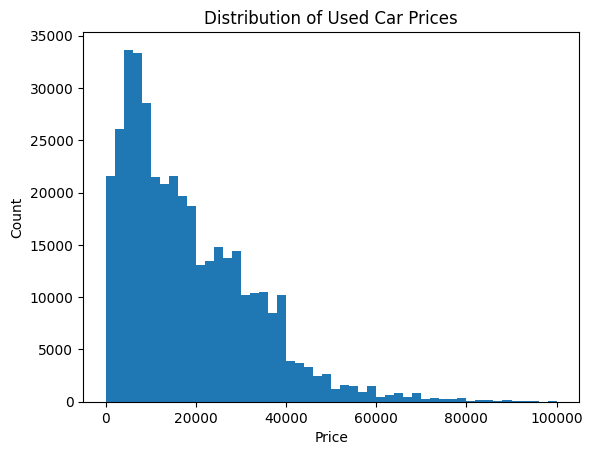

In [14]:
cars_df_viz = cars_df[(cars_df['price'] > 0) & (cars_df['price'] < 100000)]

plt.hist(cars_df_viz['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Distribution of Used Car Prices')
plt.show()

The price distribution is right-skewed. Most cars are priced between $5,000 and $10,000, and the count drops off quickly after that. There's a long tail going out toward $100,000, but not many cars are priced that high. Since price is skewed like this, a log transformation might help later on when building the regression model, since many models work better when the target variable is closer to a normal distribution.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.